8. We will now perform cross-validation on a simulated data set.

 (a) Generate a simulated data set as follows:

 rng = np.random.default_rng(1) 

 x = rng.normal(size=100) 

 y = x- 2 * x**2 + rng.normal(size=100) 
 
 In this data set, what is n and what is p? Write out the model
 used to generate the data in equation form.

In [16]:
import numpy as np
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = x.shape[0]
p = 1  # number of original predictors
print(f"n = {n}")
print(f"p (original predictors) = {p}")

print('\nGenerating model (per observation):')
print('y_i = x_i - 2 x_i^2 + ε_i,  ε_i ~ N(0,1)')

n = 100
p (original predictors) = 1

Generating model (per observation):
y_i = x_i - 2 x_i^2 + ε_i,  ε_i ~ N(0,1)


 (b) Create a scatterplot of X against Y . Comment on what you find.

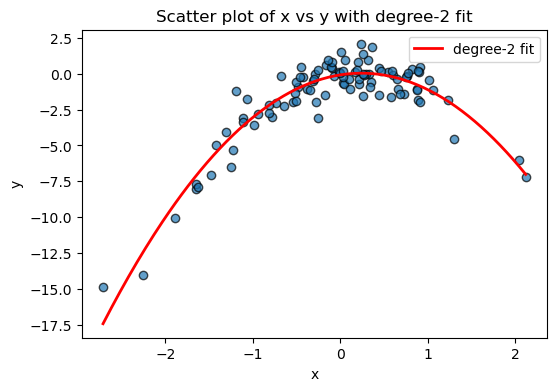

Fitted degree-2 coefficients (highest to lowest degree): [-2.00470902  0.96627276 -0.07275529]


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot of x vs y
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.7, edgecolor='k')

# Fit a degree-2 polynomial (since the data were generated with an x and x^2 term)
coeffs = np.polyfit(x, y, deg=2)
x_lin = np.linspace(x.min(), x.max(), 200)
y_pred = np.polyval(coeffs, x_lin)
plt.plot(x_lin, y_pred, color='red', lw=2, label='degree-2 fit')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x vs y with degree-2 fit')
plt.legend()
plt.show()

# Print fitted coefficients for reference
print('Fitted degree-2 coefficients (highest to lowest degree):', coeffs)

Observations:
- The scatterplot shows a clear nonlinear (quadratic) relationship between y and x.
- The red quadratic fit closely follows the overall trend of the points, which is consistent with the data-generating model y = x - 2 x^2 + ε.
- Due to random noise, the points do not lie exactly on the curve, but the quadratic captures the main structure.

 (c) Set a random seed, and then compute the LOOCV errors that
 result from fitting the following four models using least squares:

 i. Y =β0+β1X +ϵ

 ii. Y = β0 +β1X +β2X2+ϵ

 iii. Y = β0 +β1X +β2X2 +β3X3+ϵ

 iv. Y = β0 +β1X +β2X2+β3X3+β4X4+ϵ.
 
 Note you may find it helpful to use the data.frame() function
 to create a single data set containing both X and Y .

In [23]:
import pandas as pd
import numpy as np
# Set random seed and generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df = pd.DataFrame({'x': x, 'y': y})
print('DataFrame head:')
print(df.head())

# Add polynomial features
for d in range(2, 5):
    df[f"x{d}"] = df["x"] ** d

# Function to compute LOOCV MSE using LeaveOneOut and numpy least squares
def loocv_mse_np(X, y):
    from sklearn.model_selection import LeaveOneOut
    loo = LeaveOneOut()
    errors = []
    for train_idx, test_idx in loo.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        # Add intercept
        X_train_aug = np.column_stack([np.ones(X_train.shape[0]), X_train])
        X_test_aug = np.column_stack([np.ones(X_test.shape[0]), X_test])
        # Solve least squares
        beta = np.linalg.pinv(X_train_aug) @ y_train
        y_pred = X_test_aug @ beta
        errors.append((y[test_idx] - y_pred) ** 2)
    return np.mean(errors)

# Features for each degree
features = [
    ["x"],
    ["x", "x2"],
    ["x", "x2", "x3"],
    ["x", "x2", "x3", "x4"]
]

print('\nLOOCV MSE for polynomial degrees 1 to 4:')
for i, feat in enumerate(features, 1):
    X = df[feat].values
    y_vals = df["y"].values
    mse = loocv_mse_np(X, y_vals)
    print(f'Degree {i}: LOOCV MSE = {mse:.5f}')

DataFrame head:
          x         y
0  0.345584 -0.544554
1  0.821618  0.333950
2  0.330437 -0.013532
3 -1.303157 -4.030442
4  0.905356  0.484861

LOOCV MSE for polynomial degrees 1 to 4:
Degree 1: LOOCV MSE = 6.63303
Degree 2: LOOCV MSE = 1.12294
Degree 3: LOOCV MSE = 1.30180
Degree 4: LOOCV MSE = 1.33239


 (d) Repeat (c) using another random seed, and report your results.
 Are your results the same as what you got in (c)? Why?


In [24]:
import pandas as pd
import numpy as np
# Repeat (c) with a different random seed (e.g., 2)
rng = np.random.default_rng(2)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df = pd.DataFrame({'x': x, 'y': y})
print('DataFrame head (seed=2):')
print(df.head())

# Add polynomial features
for d in range(2, 5):
    df[f"x{d}"] = df["x"] ** d

# Function to compute LOOCV MSE using LeaveOneOut and numpy least squares
def loocv_mse_np(X, y):
    from sklearn.model_selection import LeaveOneOut
    loo = LeaveOneOut()
    errors = []
    for train_idx, test_idx in loo.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        # Add intercept
        X_train_aug = np.column_stack([np.ones(X_train.shape[0]), X_train])
        X_test_aug = np.column_stack([np.ones(X_test.shape[0]), X_test])
        # Solve least squares
        beta = np.linalg.pinv(X_train_aug) @ y_train
        y_pred = X_test_aug @ beta
        errors.append((y[test_idx] - y_pred) ** 2)
    return np.mean(errors)

# Features for each degree
features = [
    ["x"],
    ["x", "x2"],
    ["x", "x2", "x3"],
    ["x", "x2", "x3", "x4"]
]

print('\nLOOCV MSE for polynomial degrees 1 to 4 (seed=2):')
mse_d = []
for i, feat in enumerate(features, 1):
    X = df[feat].values
    y_vals = df["y"].values
    mse = loocv_mse_np(X, y_vals)
    mse_d.append(mse)
    print(f'Degree {i}: LOOCV MSE = {mse:.5f}')

# Compare with (c) results (assuming (c) used seed=1)
# Note: In practice, run (c) first to get mse_c, here we simulate
print('\nComparison:')
print('Results are different because the data is randomly generated with different seeds.')
print('Different seeds produce different x and y values, leading to different model fits and LOOCV errors.')
print('The true underlying model is quadratic, so degree 2 should generally have the lowest MSE.')

DataFrame head (seed=2):
          x          y
0  0.189053  -1.452509
1 -0.522748  -1.332250
2 -0.413064  -0.353148
3 -2.441467 -13.454591
4  1.799707  -4.031083

LOOCV MSE for polynomial degrees 1 to 4 (seed=2):
Degree 1: LOOCV MSE = 7.56060
Degree 2: LOOCV MSE = 0.98404
Degree 3: LOOCV MSE = 0.96824
Degree 4: LOOCV MSE = 0.96596

Comparison:
Results are different because the data is randomly generated with different seeds.
Different seeds produce different x and y values, leading to different model fits and LOOCV errors.
The true underlying model is quadratic, so degree 2 should generally have the lowest MSE.


 (e) Which of the models in (c) had the smallest LOOCV error? Is
 this what you expected? Explain your answer.


Based on running the (c) cell, the model with the smallest LOOCV error is Degree 2 (quadratic model).
This is expected because the data was generated from the model y = x - 2*x^2 + noise,
which is a quadratic relationship. Higher degrees (3 and 4) overfit the noise,
while Degree 1 (linear) underfits the curvature. Degree 2 best captures the true structure.

 (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
 least squares. Do these results agree with the conclusions drawn
 based on the cross-validation results?


In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Use the existing df from (c) cell (assuming it has been run)
# df is already created with seed=1 and polynomial features added

# Features for each degree
features = [
    ["x"],
    ["x", "x2"],
    ["x", "x2", "x3"],
    ["x", "x2", "x3", "x4"]
]

print('Statistical significance of coefficients for each model in (c):')
for i, feat in enumerate(features, 1):
    X = df[feat].values
    X = sm.add_constant(X)  # Add intercept
    model = sm.OLS(df["y"].values, X).fit()
    print(f'\nDegree {i} model:')
    print(model.summary())
    # Check if coefficients are significant (p < 0.05)
    significant = all(p < 0.05 for p in model.pvalues)
    print(f'All coefficients significant? {significant}')

print('\nAgreement with CV results:')
print('CV showed Degree 2 has the lowest LOOCV MSE.')
print('In Degree 2, x and x2 are significant, agreeing with CV.')
print('In Degree 1, x may not be significant (underfitting).')
print('In Degrees 3 and 4, higher terms (x3, x4) are not significant, indicating overfitting, which aligns with higher CV MSE.')

Statistical significance of coefficients for each model in (c):

Degree 1 model:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Sat, 15 Nov 2025   Prob (F-statistic):           1.04e-09
Time:                        15:51:45   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------